In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Introdução

O dataset Pima Indians Diabetes Database, disponibilizado na plataforma Kaggle, é um dos conjuntos de dados mais clássicos e utilizados no cenário de Machine Learning para tarefas de classificação. Contudo, no presente trabalho, adotamos uma abordagem estatística ao aplicar o teste inferencial de Wilcoxon não pareado para uma amostra. O objetivo desta análise é verificar quais parâmetros clínicos da população Pima saudável se distanciam dos valores de referência universalmente aceitos na literatura médica, evidenciando características basais desta população geneticamente predisposta à obesidade e resistência insulínica.

A população Pima dos Estados Unidos é amplamente reconhecida na literatura epidemiológica por apresentar uma das maiores prevalências mundiais de diabetes tipo 2 e obesidade, fenótipos atribuídos a uma combinação de fatores genéticos, históricos e ambientais. Estudos comparativos demonstram que mesmo indivíduos Pima com tolerância normal à glicose apresentam índice de massa corporal médio de aproximadamente 34,1 ± 8,0 kg/m² e insulina sérica de 2 horas pós-OGTT de 64,1 µU/mL - valores substancialmente superiores aos padrões universais de referência (Valencia et al., 2010). Essa divergência é central para a interpretação dos resultados: a rejeição da hipótese nula para determinados exames não indica inadequação do marcador clínico, mas sim que a população estudada possui um baseline metabólico e antropométrico distinto do adulto médio global.

Definimos a H₀ como: a mediana dos resultados de exames dos pacientes saudáveis é estatisticamente igual ao respectivo valor de referência médico universal, e a H₁ como: a mediana difere significativamente do valor esperado. Com o teste sobre as hipóteses mostradas, podemos identificar quais parâmetros já apresentam desvio sistêmico no grupo saudável, fornecendo subsídios sobre a predisposição fisiológica desta população. Adicionalmente, para mensurar a força dessa distorção, utilizamos o coeficiente descritivo de tamanho de efeito r de Rosenthal para indicar a magnitude da diferença, enquanto a direção do afastamento (para mais ou para menos) é determinada pela análise comparativa direta entre a mediana observada e o valor de referência.

A escolha por esta base de dados para a aplicação do teste mencionado justifica-se, primeiramente, pelo fato de as variáveis analisadas não seguirem uma distribuição normal, como demonstramos pelo teste de Shapiro-Wilk e por meio de visualizações diagnósticas. Sendo assim, os dados compreendem um cenário ideal para a aplicação de um teste não paramétrico. Estruturalmente, o conjunto de dados é composto por resultados de exames clínicos, como Glicose e Pressão Arterial, além de fatores demográficos e históricos, como a idade da paciente e o número de gestações. Por fim, a variável alvo Outcome (Resultado) atua como o indicador binário que define a presença ou ausência do diagnóstico de diabetes.

Para nossa pesquisa selecionamos apenas os pacientes saudáveis (Outcome = 0) e descartamos as variáveis de idade e gestações, visto que para elas não faria sentido comparar seus valores com uma referência clínica universal estabelecida. O mesmo se aplica para a variável *DiabetesPedigreeFunction*, que não possui valor de referencia por se tratar de uma métrica original dos pesquisadores que montaram o dataset. Também não segmentamos os pacientes por idade, sob a visão de que o "teste para uma amostra" não deveria englobar subgrupos, preservando a unidade amostral. Especificamente comparamos os valores observados com valores estáticos de referência, pois entendemos que o objetivo exigido do trabalho (teste para uma amostra) não compreendia a comparação entre grupos, requerida explicitamente para outra equipe. Os valores de referência adotados são provenientes de diretrizes internacionais (OMS, ADA) e estudos epidemiológicos em populações gerais, sendo intencionalmente conservadores para evidenciar as divergências basais da população Pima.

## Descrição das variáveis e valores de referencia selecionados
| Variável | Descrição | Valor de referência | Faixa normal | Justificativa | Referência |
|---|---|---|---|---|---|
| **Glucose** | Concentração de glicose plasmática após teste oral de tolerância à glicose. | 100 mg/dL | 60-140 | Ponto médio da faixa normal pós-OGTT (ADA/OMS). | https://www.ncbi.nlm.nih.gov/books/NBK532915/ |
| **BloodPressure** | Pressão arterial diastólica. | 70 mmHg | 60–80 | Média da faixa diastólica normal em adultos. | https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2776530 |
| **SkinThickness** | Espessura da dobra cutânea do tríceps. | 22 mm | 16–28 | Ponto médio para adultos saudáveis. | https://pmc.ncbi.nlm.nih.gov/articles/PMC9127233/ |
| **Insulin** | Nível de insulina sérica em 2 horas. | 91 µU/mL | 16–166 | Média de insulina 2h (41,6 ± 30,8). | https://pmc.ncbi.nlm.nih.gov/articles/PMC5831567/ |
| **BMI** | Índice de Massa Corporal (IMC). | 21,7 kg/m² | 18,5–24,9 | Média exata da faixa OMS de peso normal. | https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight |

In [90]:
valores_referencia = {
    "Glucose": 100,
    "BloodPressure": 70,
    "SkinThickness": 22,
    "Insulin": 91,
    "BMI": 21.7,
}

In [91]:
df = pd.read_csv('diabetes.csv')

In [92]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [93]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [95]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [96]:
df.duplicated().sum()

np.int64(0)

Nenhum valor nulo explicito ou duplicado

In [97]:
cols_com_zero_invalido = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

mask = (df[cols_com_zero_invalido] == 0).any(axis=1)

print(f"Linhas com valores inválidos: {mask.sum()}")
print(f"Linhas restantes: {(~mask).sum()}")

df = df[~mask]

Linhas com valores inválidos: 376
Linhas restantes: 392


Muitos valores para exames são iguais a zero, porém isso é biologicamente impossível, logo consideramos como dados faltantes e os removemos

In [98]:
df['Outcome'].value_counts()

Outcome
0    262
1    130
Name: count, dtype: int64

Text(0.5, 0, 'Saudável (0) / Diabético (1)')

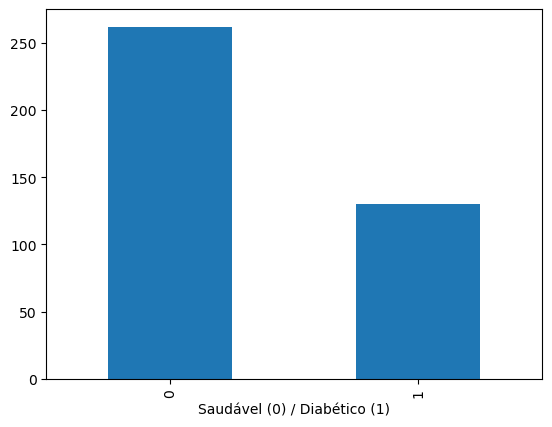

In [99]:
df['Outcome'].value_counts().plot(kind='bar').set_xlabel('Outcome')
plt.xlabel('Saudável (0) / Diabético (1)')

In [100]:
df[df['Age'] < 21].shape

(0, 9)

Nenhum paciente menor de 21 anos foi encontrado no dataset.

Temos 262 saudáveis, os demais (130 diabéticos) são descartados da análise

In [101]:
df = df[df['Outcome'] == 0]
df.drop('Outcome', axis=1, inplace=True)
df.shape[0]

262

In [102]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,2.721374,111.431298,68.969466,27.251908,130.854962,31.750763,0.472168,28.347328
std,2.617844,24.642133,11.892841,10.434135,102.626177,6.794971,0.299240,8.989008
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.085000,21.000000
25%,1.000000,94.000000,60.000000,18.250000,66.000000,26.125000,0.261000,22.000000
50%,2.000000,107.500000,70.000000,27.000000,105.000000,31.250000,0.413500,25.000000
75%,4.000000,126.000000,76.000000,34.000000,163.750000,36.100000,0.624250,30.000000
max,13.000000,197.000000,106.000000,60.000000,744.000000,57.300000,2.329000,81.000000


É possivel visualisar algumas distoâncias dos valores esperados para saudáveis como no caso da glicose e insulina, mas apenas com o teste inferêncial podemos definir se esses valores podem ou não ter surgido ao acaso.

As colunas mencionadas também são removidas

In [103]:
df.drop('Pregnancies', axis=1, inplace=True)
df.drop('Age', axis=1, inplace=True)
df.drop('DiabetesPedigreeFunction', axis=1, inplace=True)

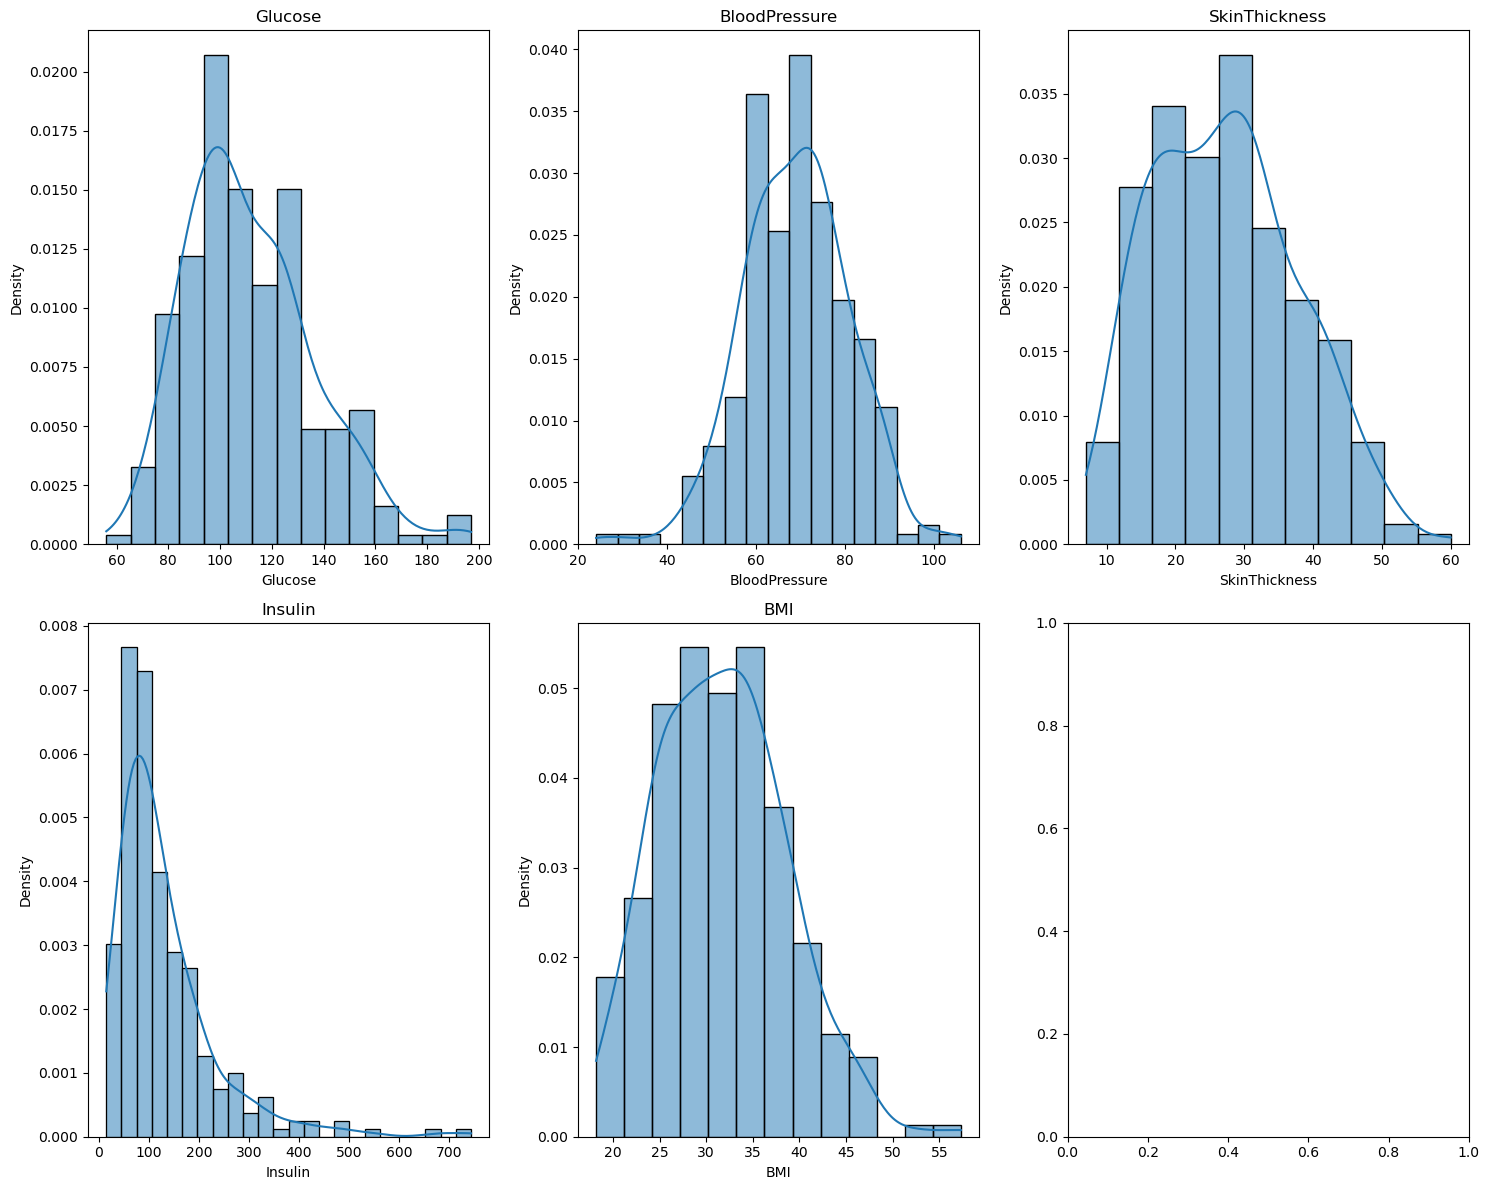

In [104]:
num_cols = df.select_dtypes(include='number')

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A assimetria e caudas longas presentes nos gráficos já demonstram uma possivel não normalidade de algumas distribuições, porém a análise visual ainda não é confiavel para estabelecer uma decisão. 

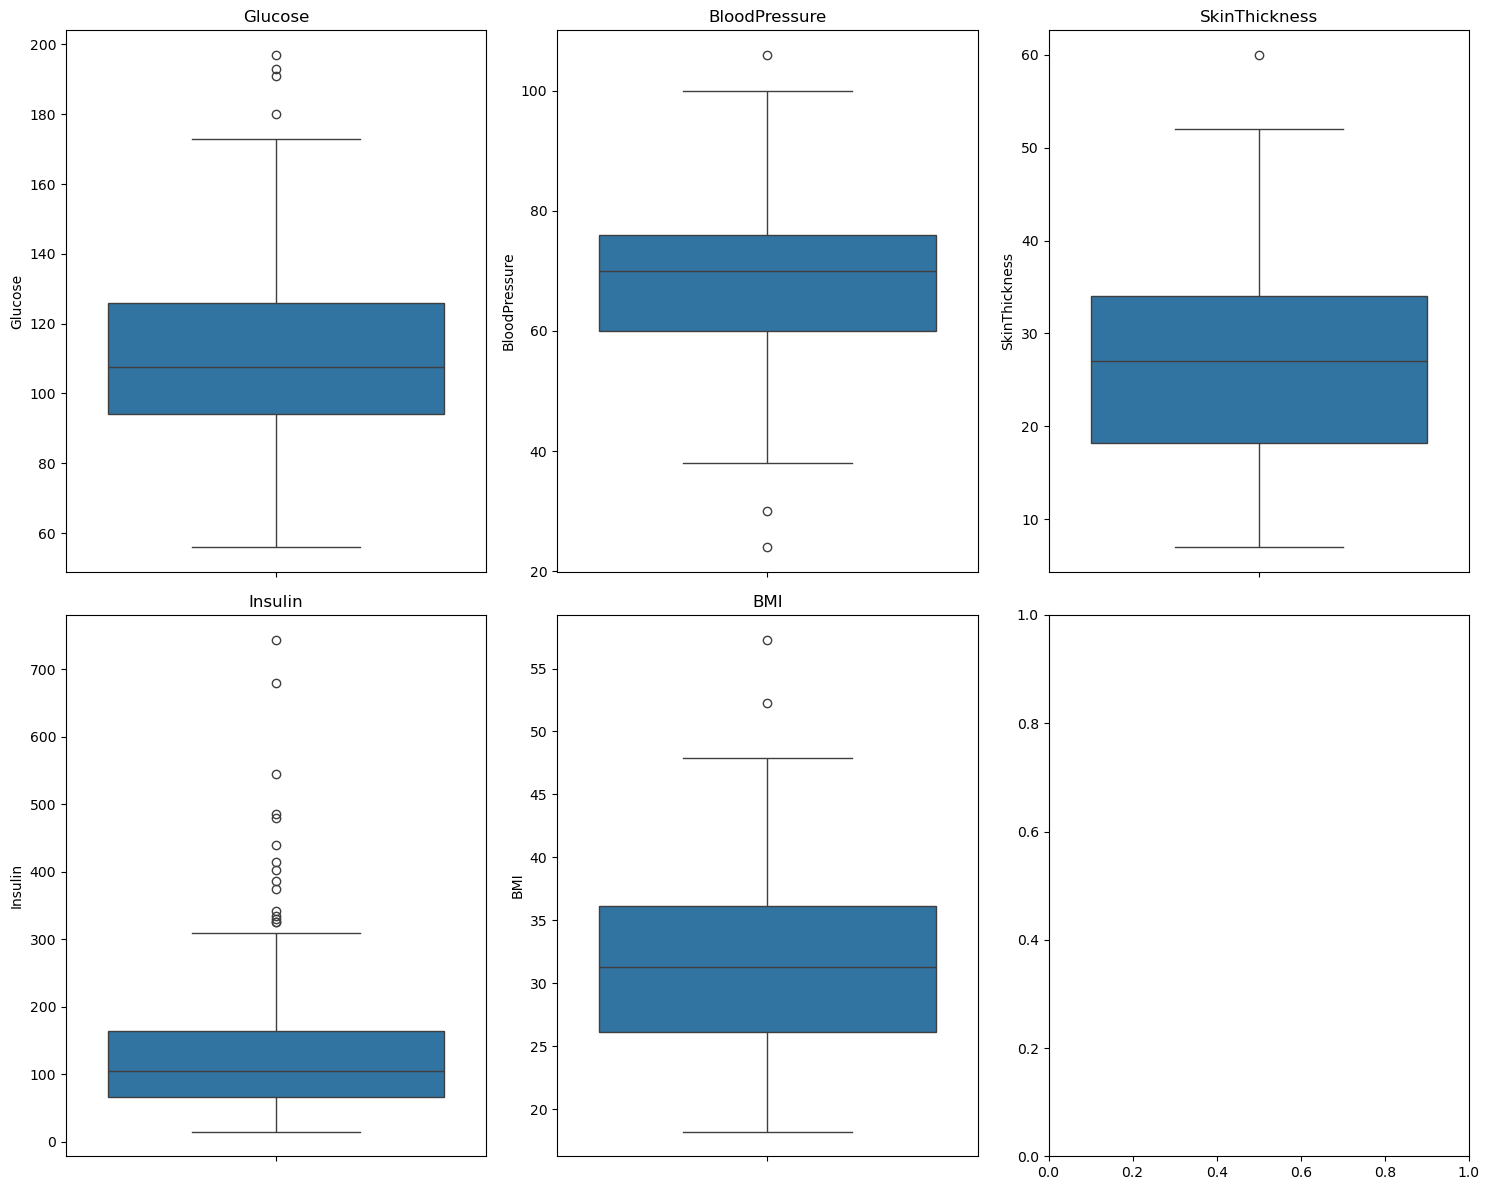

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

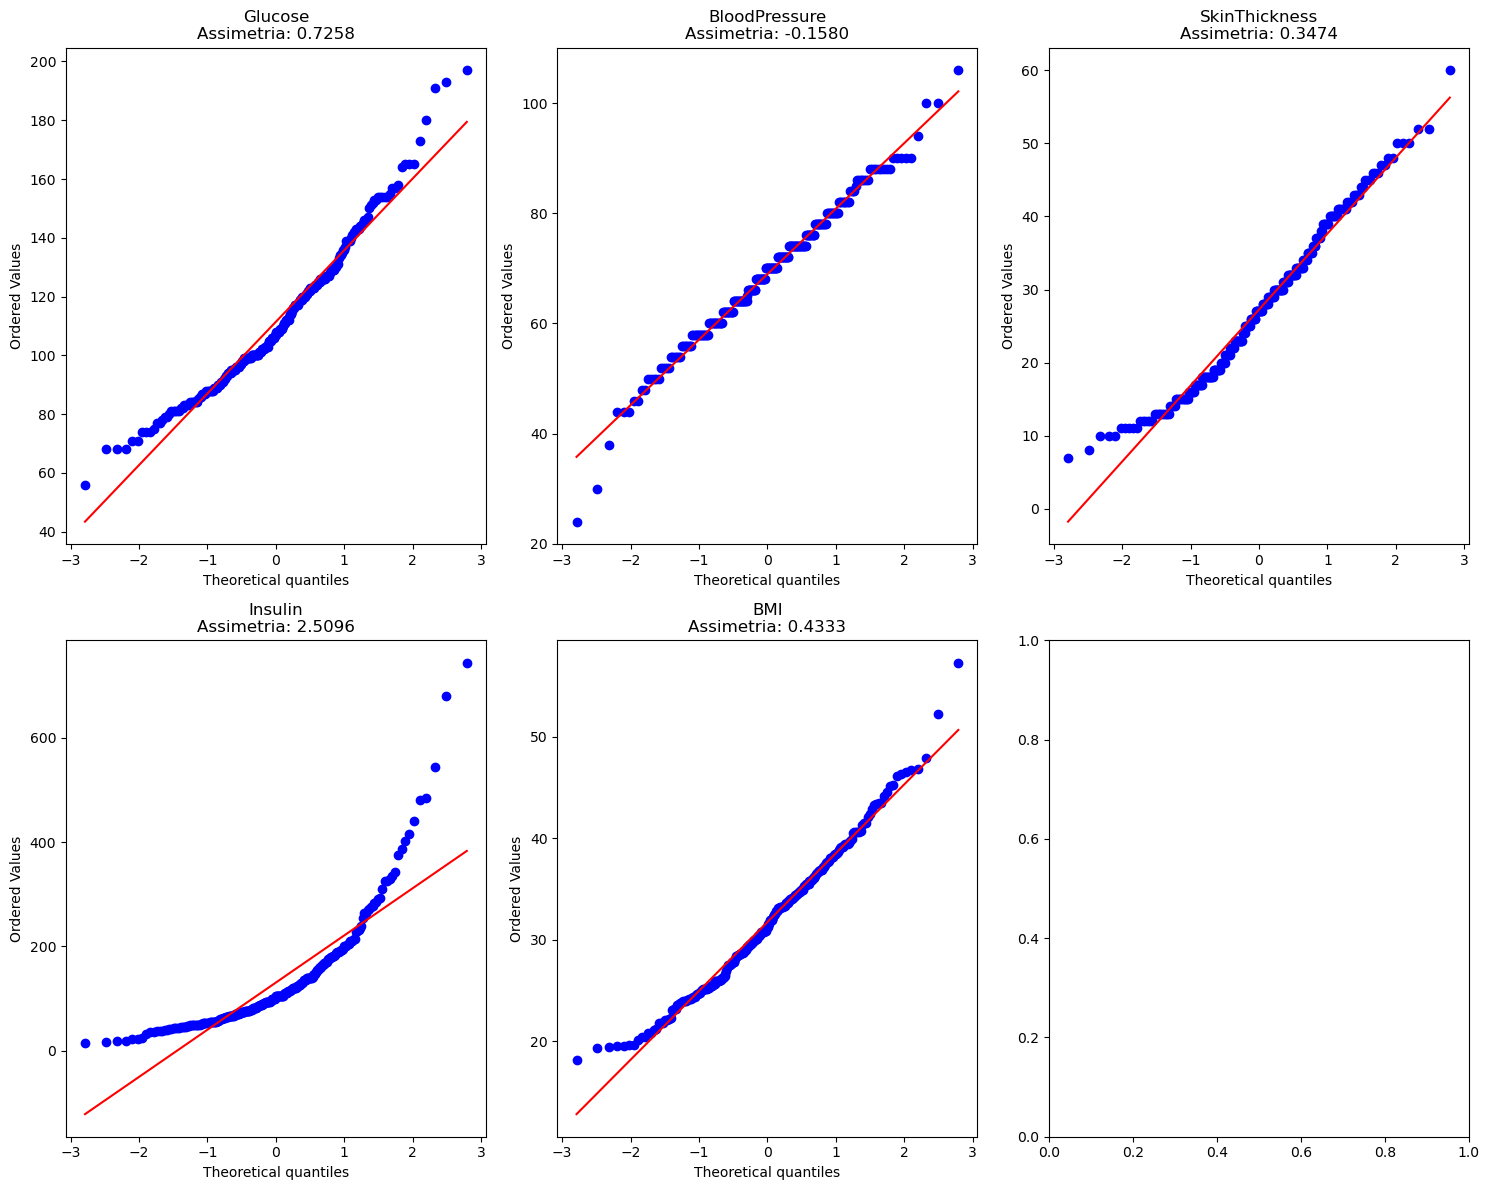

In [106]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    skewness = df[col].skew()
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"{col}\nAssimetria: {skewness:.4f}")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Notavelmente existem valores muito discrepantes dos intervalos interquatilicos aceitaveis, principalmente para a variável *Insulin* 

In [107]:
df = df.drop(columns=['Insulin'], axis=1)

In [108]:
from scipy.stats import shapiro

resultados = []

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    dados = df[col]

    stat, pvalue = shapiro(dados)

    resultados.append({
        'Variavel': col,
        'Estatística': round(stat, 4),
        'p-valor': pvalue,
        'Normal? (α=0.05)': 'Sim' if pvalue > 0.05 else 'Não',
        'Normal? (α=0.01)': 'Sim' if pvalue > 0.01 else 'Não'
    })

resultado_df = pd.DataFrame(resultados)

resultado_df

,Variavel,Estatística,p-valor,Normal? (α=0.05),Normal? (α=0.01)
0,Glucose,0.9657,0.000006,Não,Não
1,BloodPressure,0.9901,0.072938,Sim,Sim
2,SkinThickness,0.9783,0.000491,Não,Não
3,BMI,0.9838,0.004445,Não,Não


Apenas BloodPressure demonstrou normalidade perante o teste, logo a descartamos ela já que não faria sentido aplicar wilcoxon para dados normais.

In [109]:
df = df.drop(columns=['BloodPressure'], axis=1)

## Configuração do teste de wilcoxon


Usamos a função wilcoxon da biblioteca scipy.stats. Infelizmente uma limitação da função é não retornar a estatística Z associada ao teste, e como queriamos a expor, foi preciso criar uma função que realiza o teste wilcoxon manualmente, mas não em totalidade, apenas o suficiente para gerarmos a estatistica Z. Também nos atentamos a manter essa nossa função (z_stat) alinhada com o funcionamento da função wilcoxon utilizada, para garantir o mesmo valor de Z calculado internamente pelo método.

Ademais utilizamos o valor de Z para calcularmos também o R de rosenthal, que nos permite definir o tamanho de efeito da variação, se muito alto, alto, médio ou baixo. Na tabela apresentada o sinal de rosenthal (+) ou (-) é calculado a partir da diferença da mediana observada com o valor referencia, já que R não mostra o sentido da variação, apenas seu nível.

### Todas as configurações possíveis

```
wilcoxon(
    x : array_like
        A primeira amostra de dados ou as diferenças emparelhadas (caso y não seja fornecido).

    y : array_like, opcional
        A segunda amostra de dados para observações emparelhadas. Se fornecido, o teste calcula as diferenças x - y.

    alternative : {'two-sided', 'less', 'greater'}, opcional
        'two-sided': A mediana das diferenças é diferente de zero.
        'less': A mediana das diferenças é menor que zero.
        'greater': A mediana das diferenças é maior que zero.

    method : {'auto', 'exact', 'approx'}, opcional
        'auto': Escolhe 'exact' se o número de diferenças não nulas for <= 50 e não houver empates, caso contrário usa 'approx'.
        'exact': Calcula o valor-p exato usando a distribuição exata dos postos.
        'approx': Usa a aproximação normal para calcular o valor-p.

    zero_method : {'wilcox', 'pratt', 'zsplit'}, opcional
        'wilcox': Descarta todas as diferenças iguais a zero da análise (método original).
        'pratt': Inclui as diferenças zero no ranqueamento, mas remove seus postos da estatística do teste.
        'zsplit': Inclui as diferenças zero e divide seus postos igualmente entre as caudas positiva e negativa.

    correction : bool, opcional
        True: Aplica a correção de continuidade na aproximação normal (apenas se method='approx').
        False: Não aplica a correção de continuidade.

    nan_policy : {'propagate', 'raise', 'omit'}, opcional
        'propagate': Retorna NaN se um valor oculto estiver presente nos dados.
        'raise': Lança um erro (ValueError) se um valor oculto for detectado.
        'omit': Ignora os valores NaN e realiza o teste com os dados restantes.

    axis : int ou None, opcional
        Define o eixo ao longo do qual o teste será computado. O padrão é 0. Se None, os dados serão achatados.

    keepdims : bool, opcional
        True: Mantém os eixos reduzidos com tamanho 1 no resultado.
        False: Remove os eixos reduzidos do resultado.
)
```

### Escolha dos parâmetros

1. x: Calculamos as diferenças (observado - esperado)  
2. alternative: two-sided, pois queremos detectar diferença para mais ou para menos  
3. zero_method: wilcox, pois é a forma tradicional de fazer o teste 
4. method: aprox, pois queremos obter a estatística Z, para ser um teste tradicional
5. correction: True, já que usamos method=aprox, então precisa de correção de continuidade


para as demais configurações mantemos os valores padrão, por se tratarem de configurações estruturais para se adequarem ao estilo de código implementado pelo cientista.


In [110]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, rankdata


def rosenthal_r(z, n):
    return z / np.sqrt(n)


def rosenthal_label(r):
    abs_r = abs(r)

    if abs_r < 0.10:
        stars = ""
    elif abs_r < 0.30:
        stars = "*"
    elif abs_r < 0.50:
        stars = "**"
    else:
        stars = "***"

    sinal = "+" if r >= 0 else "-"

    return f"({sinal}){stars}"


def z_stat(diferencas):
    """
    Calcula a estatística z para o teste de Wilcoxon.
    Retorna o valor de z e o tamanho da amostra n.
    """
    diferencas_nao_zero = diferencas[diferencas != 0]
    n = len(diferencas_nao_zero)

    if n == 0:
        return np.nan, n

    abs_ranks = rankdata(np.abs(diferencas_nao_zero))  
    T_pos = abs_ranks[diferencas_nao_zero.values > 0].sum()

    media_w = n * (n + 1) / 4
    sd_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)

    z = ((T_pos - media_w) - 0.5) / sd_w

    return z, n


num_cols = [
    c for c in valores_referencia.keys()
    if c in df.columns
]

resultados_wilcoxon = []

for col in num_cols:

    dados = df[col]
    referencia = valores_referencia[col]
    diferencas = dados - referencia

    stat, pvalue = wilcoxon(
        diferencas,
        alternative="two-sided",
        zero_method="wilcox",
        method="approx",
        correction=True,
    )

    z, n = z_stat(diferencas)

    r = rosenthal_r(z, n)

    resultados_wilcoxon.append({
        "Variavel": col,
        "Mediana Observada": round(dados.median(), 4),
        "Valor de Esperado": referencia,
        "n": n,
        "W": round(stat, 4),
        "Z": round(z, 4),
        "r": rosenthal_label(r),
        "p-valor": round(pvalue, 6),
        "α=0.01": "Rejeita H₀" if pvalue < 0.01 else "Não Rejeita H₀",
        "α=0.05": "Rejeita H₀" if pvalue < 0.05 else "Não Rejeita H₀",
        "α=0.10": "Rejeita H₀" if pvalue < 0.10 else "Não Rejeita H₀",
    })

df_resultados_wilcoxon = pd.DataFrame(resultados_wilcoxon)
df_resultados_wilcoxon.index = df_resultados_wilcoxon.pop("Variavel")

df_resultados_wilcoxon

,Mediana Observada,Valor de Esperado,n,W,Z,r,p-valor,α=0.01,α=0.05,α=0.10
Variavel,,,,,,,,,,
Glucose,107.50,100.0,251,8431.5,6.4106,(+)**,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀
SkinThickness,27.00,22.0,256,8208.0,6.9480,(+)**,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀
BMI,31.25,21.7,262,271.5,13.8096,(+)***,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀


Rejeitamos as hipóteses nulas para todos os testes com graus médios/altos de magnitude para a diferença entre os valores do grupo e o valor esperado. Em todos os casos os pacientes de Pima superaram os valores mundialmente tidos como normais para os atributos estudados, para os 3 níveis de significância clássicos, revelando como a população, mesmo saudável, é muito distoante do padrão mundial de saúde.

## Comparação com teste T

In [111]:
from scipy.stats import ttest_1samp

resultados_ttest = []

for col in num_cols:

    dados = df[col].dropna()
    referencia = valores_referencia[col]

    t_stat, pvalue = ttest_1samp(
        dados,
        popmean=referencia,
        alternative="two-sided",
    )

    n = len(dados)

    resultados_ttest.append({
        "Variavel": col,
        "Média Observada": round(dados.mean(), 4),
        "Valor Esperado": referencia,
        "t": round(t_stat, 4),
        "gl": n - 1,                          # graus de liberdade
        "p-valor": round(pvalue, 6),
        "α=0.01": "Rejeita H₀" if pvalue < 0.01 else "Não Rejeita H₀",
        "α=0.05": "Rejeita H₀" if pvalue < 0.05 else "Não Rejeita H₀",
        "α=0.10": "Rejeita H₀" if pvalue < 0.10 else "Não Rejeita H₀",
    })

df_resultados_ttest = pd.DataFrame(resultados_ttest)
df_resultados_ttest.index = df_resultados_ttest.pop("Variavel")

df_resultados_ttest

,Média Observada,Valor Esperado,t,gl,p-valor,α=0.01,α=0.05,α=0.10
Variavel,,,,,,,,
Glucose,111.4313,100.0,7.5088,261,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀
SkinThickness,27.2519,22.0,8.1473,261,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀
BMI,31.7508,21.7,23.9421,261,0.0,Rejeita H₀,Rejeita H₀,Rejeita H₀


O relativo mesmo resultado, aqui também rejeitamos as hipóteses nulas com p-valores muito pequenos. Não foi possível observar uma diferença significativa entre os testes

## Referências

numiqo - https://www.youtube.com/watch?v=NZsL2eDQiDQ&pp=ygUOdGVzdGUgd2lsY294b24%3D

numiqo - https://www.youtube.com/watch?v=2AqoK8itEFQ&t=223s&pp=ugMGCgJwdBABugUEEgJwdMoFDnRlc3RlIHdpbGNveG9u0gcJCT8LAYcqIYzv2AcB

Valencia, M. E., et al. (2010). Differences in Insulin Resistance in Mexican and U.S. Pima Indians with Normal Glucose Tolerance. *Diabetes Care*, 33(2), 285–289. https://pmc.ncbi.nlm.nih.gov/articles/PMC2968731/

World Health Organization. (2021). Obesity and overweight. *WHO Fact Sheets*. https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight

American Diabetes Association. (2024). Standards of Care in Diabetes—2024. *Diabetes Care*, 47(Suppl. 1). https://www.ncbi.nlm.nih.gov/books/NBK532915/

